# Face Emotion Recognition — Simple Lab

## What are we doing?

We teach the computer to look at a **face photo** and guess the **emotion**:
`anger`, `fear`, `happiness`, `neutral`, `sadness`, `surprise`

```
Photo  →  Find face  →  LBP numbers  →  SVM  →  Emotion
```

| Library | Used for |
|---------|----------|
| **OpenCV** | Read images + detect face (Haar Cascade) |
| **scikit-image** | LBP — face texture → numbers |
| **scikit-learn** | SVM — classify emotion |
| **matplotlib** | Show images |
| **ipywidgets** | Upload your own photo (last step) |

**Files needed:** `haarcascade_frontalface_default.xml` + `CK+/train/` + `CK+/test/`

> Run every cell **top to bottom** (Shift + Enter).

## Step 1 — Install (only if needed)

In [2]:
# !pip install opencv-python scikit-image scikit-learn matplotlib numpy ipywidgets -q

## Step 2 — Setup

In [3]:
import os
import zipfile
import urllib.request
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# ── Detect environment ────────────────────────────────────────────────────────
IN_COLAB = 'google.colab' in str(get_ipython())
LAB_DIR = Path('/content') if IN_COLAB else Path.cwd()
print('Running in:', 'Google Colab' if IN_COLAB else 'Local Jupyter')

# ── Step 1: Unzip CK+.zip if not already unzipped ────────────────────────────
zip_path = LAB_DIR / 'CK+.zip'
ck_train = LAB_DIR / 'CK+' / 'train'

if not ck_train.is_dir():
    if zip_path.is_file():
        print('Unzipping CK+.zip ...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(LAB_DIR)
        print('Done unzipping.')
    else:
        print('WARNING: CK+.zip not found. Upload it first.')
else:
    print('CK+ dataset already unzipped.')

# ── Step 2: Get Haar Cascade (use OpenCV built-in — always available) ─────────
HAAR_FILE = Path(cv2.data.haarcascades) / 'haarcascade_frontalface_default.xml'
print('Haar cascade:', HAAR_FILE)

# ── Paths ────────────────────────────────────────────────────────────────────
TRAIN_PATH = LAB_DIR / 'CK+' / 'train'
TEST_PATH  = LAB_DIR / 'CK+' / 'test'
MAX_PER_CLASS = 25

face_cascade = cv2.CascadeClassifier(str(HAAR_FILE))
print('Face detector ready:', not face_cascade.empty())
print('Train folder exists:', TRAIN_PATH.is_dir())
print('Test  folder exists:', TEST_PATH.is_dir())

Face detector ready: True


## Step 3 — Load photos & crop faces

- In short: load photos → crop faces → save face + emotion label for training/testing.

In [4]:
def get_face(gray_img):
    # Use Haar Cascade to find face boxes in the image
    boxes = face_cascade.detectMultiScale(gray_img, 1.1, 5, minSize=(30, 30))

    # If no face is found, use the whole image
    if len(boxes) == 0:
        return gray_img

    # Take the first detected face and crop it
    x, y, w, h = boxes[0]
    return gray_img[y:y+h, x:x+w]


def load_folder(folder, max_per_class=25):
    # This function reads images from train/ or test/ folder
    faces, labels = [], []
    folder = Path(folder)

    # Each sub-folder name is the emotion label (anger, fear, happiness, ...)
    for emotion in sorted(os.listdir(folder)):
        emotion_dir = folder / emotion
        if not emotion_dir.is_dir():
            continue

        count = 0
        # Read image files inside each emotion folder
        for img_file in sorted(emotion_dir.iterdir()):
            # Stop after max_per_class images (for faster run)
            if max_per_class and count >= max_per_class:
                break

            # Only read image files
            if img_file.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp"}:
                continue

            # Read image in grayscale
            gray = cv2.imread(str(img_file), cv2.IMREAD_GRAYSCALE)
            if gray is None:
                continue

            # Crop face and save face + label
            faces.append(get_face(gray))
            labels.append(emotion)
            count += 1

    return faces, labels

# Load training and test data
train_faces, train_labels = load_folder(TRAIN_PATH, MAX_PER_CLASS)
test_faces, test_labels = load_folder(TEST_PATH, MAX_PER_CLASS)

# Print how many images were loaded
print("Training images:", len(train_faces))
print("Test images:    ", len(test_faces))

# Print count per emotion in training data
print("\nTrain count per emotion:")
for emo, n in sorted(Counter(train_labels).items()):
    print(f"  {emo:12s} : {n}")

# Print count per emotion in test data
print("\nTest count per emotion:")
for emo, n in sorted(Counter(test_labels).items()):
    print(f"  {emo:12s} : {n}")

Training images: 138
Test images:     97

Train count per emotion:
  anger        : 25
  fear         : 18
  happiness    : 25
  neutral      : 25
  sadness      : 20
  surprise     : 25

Test count per emotion:
  anger        : 14
  fear         : 7
  happiness    : 21
  neutral      : 23
  sadness      : 8
  surprise     : 24


### 👀 Visualize training samples

One example face from **each emotion** — so students see what the data looks like.

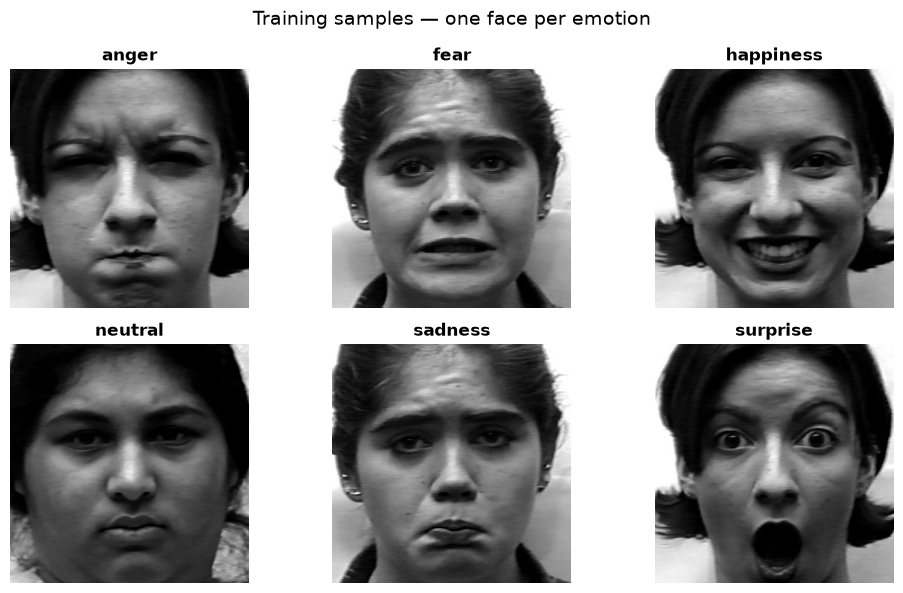

In [5]:
# Pick first face for each emotion
emotions_order = sorted(set(train_labels))
sample_idx = [train_labels.index(e) for e in emotions_order]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for ax, idx, emo in zip(axes.ravel(), sample_idx, emotions_order):
    ax.imshow(train_faces[idx], cmap="gray")
    ax.set_title(emo, fontsize=12, fontweight="bold")
    ax.axis("off")
plt.suptitle("Training samples — one face per emotion", fontsize=14)
plt.tight_layout()
plt.show()

## Step 4 — LBP features + Train SVM

**LBP idea:** compare each pixel to 8 neighbors → build a histogram of numbers → give to SVM.

In [6]:
from typing import Any


def face_to_numbers(face):
    """Convert one face into LBP histogram (numbers for SVM)."""

    # Step 1: make every face the same size
    face = cv2.resize(face, (64, 64))

    # Step 2: LBP — compare each pixel to 8 neighbors
    lbp = local_binary_pattern(face, P=8, R=1, method="uniform")

    # Step 3: histogram — count how many times each LBP value appears
    #         10 bins (same as original lab)
    hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10))

    # Step 4: normalize (proportions that sum to 1)
    hist = hist.astype(float)
    hist /= hist.sum() + 1e-6

    return hist, lbp, face


def face_to_features(face):
    """Return only the histogram (for SVM)."""
    hist, _, _ = face_to_numbers(face)
    return hist


# Step 5: convert all training/test faces to number vectors
X_train = np.array([face_to_features(f) for f in train_faces])
X_test  = np.array([face_to_features(f) for f in test_faces])

# Step 6: convert text labels to numbers (anger=0, fear=1, ...)
encoder = LabelEncoder()
y_train = encoder.fit_transform(train_labels)
y_test  = encoder.transform(test_labels)

# Step 7: train SVM
#   StandardScaler = scale features before SVM
#   SVC = Support Vector Classifier (RBF kernel, C=7)
model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=7, gamma="scale")
)
model.fit(X_train, y_train)

print("Model trained!")
print("Feature size per face:", X_train.shape[1], "numbers")


Model trained!
Feature size per face: 10 numbers


### 👀 What do these 3 pictures mean?

We take **one face** and follow 3 steps:

---

**1) Face (64×64)**  
- The cropped face, resized to the same size  
- Same input for every photo in the dataset  

---

**2) LBP map**  
- LBP compares each pixel with its **8 neighbors**  
- Similar texture → similar numbers in the map  
- It shows **face texture**, not color  

---

**3) LBP histogram → SVM input**  
This is the step SVM actually uses:

| Step | What happens |
|------|----------------|
| **A** | Look at all numbers in the LBP map |
| **B** | Count how often each value appears (bins 0–9) |
| **C** | Normalize so the counts become proportions (sum ≈ 1) |

**Result:** one list of **10 numbers** = the face “fingerprint”  
→ SVM learns: *this fingerprint = anger / happiness / …*

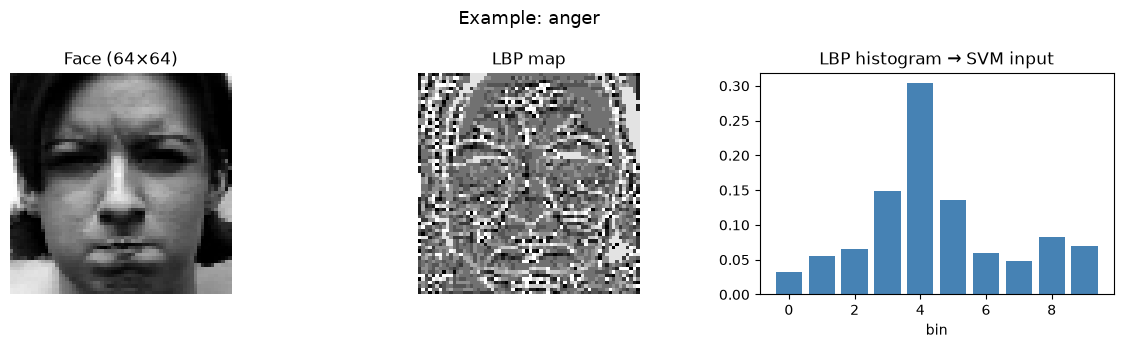

In [7]:
hist, lbp_map, face64 = face_to_numbers(train_faces[0])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].imshow(face64, cmap="gray")
axes[0].set_title("Face (64×64)")
axes[0].axis("off")

axes[1].imshow(lbp_map, cmap="gray")
axes[1].set_title("LBP map")
axes[1].axis("off")

axes[2].bar(range(len(hist)), hist, color="steelblue")
axes[2].set_title("LBP histogram → SVM input")
axes[2].set_xlabel("bin")

plt.suptitle(f"Example: {train_labels[0]}", fontsize=13)
plt.tight_layout()
plt.show()

## Step 5 — Test on sample photos

Run the model on **test photos**. In the pictures below:
- **GREEN border + CORRECT** = True label matches Predicted
- **RED border + WRONG** = prediction does not match

In [8]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
pred_labels = encoder.inverse_transform(y_pred)

correct = sum(t == p for t, p in zip(test_labels, pred_labels))
wrong = len(test_labels) - correct

print(f"Test accuracy: {acc * 100:.1f}%")
print(f"Test images:   {len(test_labels)}")
print(f"Correct:       {correct}")
print(f"Wrong:         {wrong}")

Test accuracy: 17.5%
Test images:   97
Correct:       17
Wrong:         80


Total correct: 17 out of 97
Correct at positions: [9, 16, 20, 23, 29, 34, 35, 42, 55, 59]


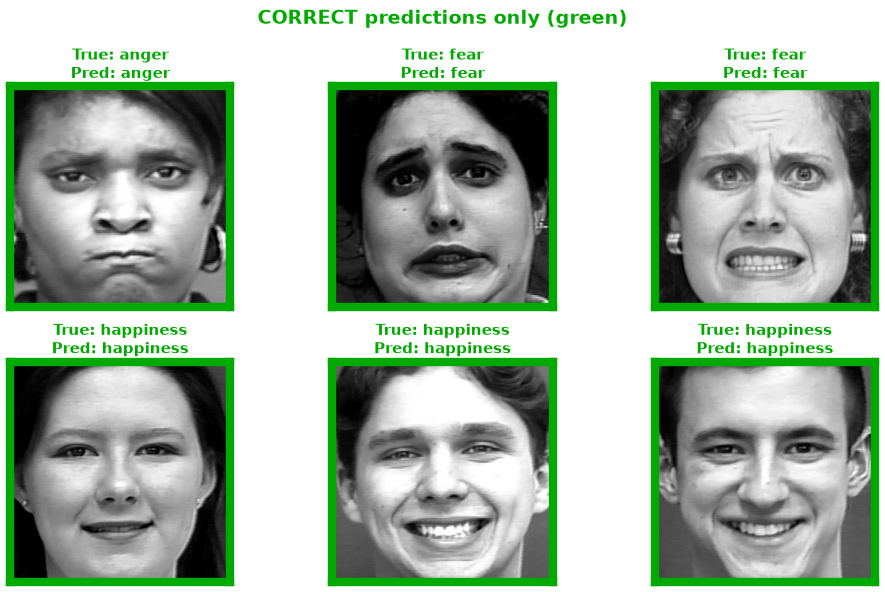

In [9]:
# Find ALL correct predictions
correct_idx = [i for i in range(len(test_labels)) if test_labels[i] == pred_labels[i]]

print(f"Total correct: {len(correct_idx)} out of {len(test_labels)}")
print("Correct at positions:", correct_idx[:10])

# Show first 6 correct ones (green)
n_show = min(6, len(correct_idx))
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for ax, i in zip(axes.ravel(), correct_idx[:n_show]):
    ax.imshow(test_faces[i], cmap="gray")
    for spine in ax.spines.values():
        spine.set_edgecolor("#00AA00")
        spine.set_linewidth(6)
    ax.set_title(
        f"True: {test_labels[i]}\nPred: {pred_labels[i]}",
        color="#00AA00", fontweight="bold", fontsize=11
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.ravel()[n_show:]:
    ax.axis("off")

plt.suptitle("CORRECT predictions only (green)", fontsize=14, fontweight="bold", color="#00AA00")
plt.tight_layout()
plt.show()

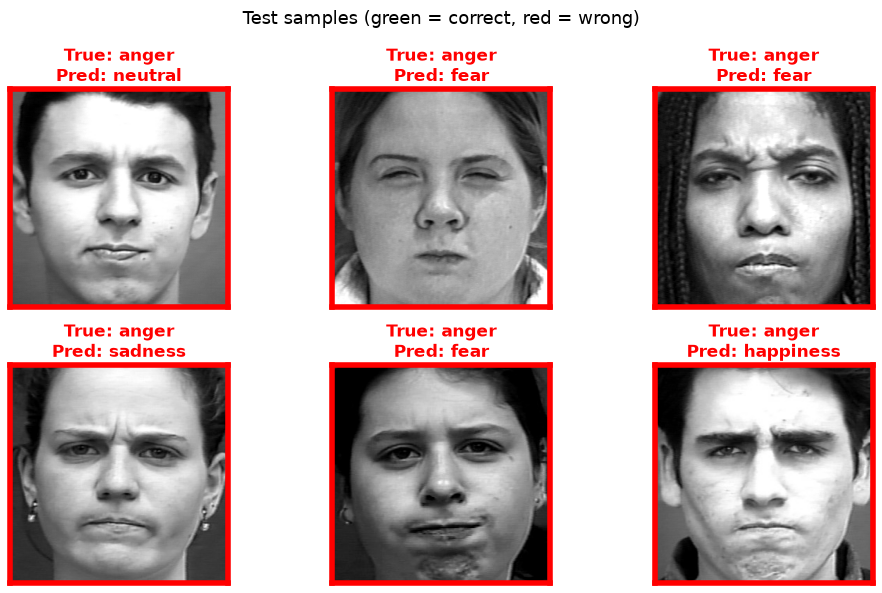

In [10]:
# Visual: 6 test samples — green border = correct, red = wrong
n_show = min(6, len(test_faces))
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for ax, i in zip(axes.ravel(), range(n_show)):
    true_l = test_labels[i]
    pred_l = pred_labels[i]
    correct = true_l == pred_l

    ax.imshow(test_faces[i], cmap="gray")
    border_color = "limegreen" if correct else "red"
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)
    ax.set_title(f"True: {true_l}\nPred: {pred_l}", color=border_color, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Test samples (green = correct, red = wrong)", fontsize=13)
plt.tight_layout()
plt.show()

## Step 6 — Upload YOUR photo & predict 🖼️

Now try it yourself! Click **Upload**, pick a face photo, and see the prediction.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output


def predict_from_image(img, title="Your photo"):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    boxes = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))

    if len(boxes) == 0:
        print("No face found — using whole image.")
        boxes = [(0, 0, gray.shape[1], gray.shape[0])]

    for (x, y, w, h) in boxes:
        face = gray[y:y+h, x:x+w]
        numbers = face_to_features(face).reshape(1, -1)
        emotion = encoder.inverse_transform(model.predict(numbers))[0]

        cv2.rectangle(rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(rgb, emotion, (x, max(y - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)
        print("Predicted emotion:", emotion)

    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()


upload = widgets.FileUpload(accept=".jpg,.jpeg,.png,.bmp", multiple=False)
output = widgets.Output()


def read_upload(upload_widget):
    """Read uploaded file — works with ipywidgets 7 (dict) and 8 (tuple)."""
    val = upload_widget.value
    if not val:
        return None, None
    # ipywidgets 8+: tuple of dicts
    if isinstance(val, tuple):
        info = val[0]
        name = info.get("name", "uploaded.jpg")
        content = info.get("content")
        return name, content
    # ipywidgets 7: dict
    if isinstance(val, dict):
        info = list(val.values())[0]
        name = info["metadata"]["name"]
        content = info["content"]
        return name, content
    return None, None


def on_upload(change):
    with output:
        clear_output(wait=True)
        name, content = read_upload(upload)
        if content is None:
            return
        arr = np.frombuffer(content, dtype=np.uint8)
        img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        if img is None:
            print("Could not read image. Try JPG or PNG.")
            return
        print("File:", name)
        predict_from_image(img)

upload.observe(on_upload, names="value")
display(widgets.VBox([widgets.Label("📁 Upload a face photo:"), upload, output]))

## Done! 🎉

**Face detect → LBP → SVM → Emotion**

1. Saw training samples
2. Saw LBP features
3. Tested on sample photos
4. Uploaded your own photo